# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [1]:
import pandas as pd

df = pd.DataFrame({
    'Gene': ['isg15', 'hur', 'ifna', 'tnfa', 'atpsf1a'],
    'Serina': [3, 2, 1, 3, 2],
    'Cisteina': [2, 1, 3, 2, 4],
    'Lisina': [1, 2, 2, 1, 3],
    'Valina': [2, 1, 2, 2, 1]
})

df.to_csv('frequencias_aa.csv', index=False)
df = pd.read_csv('frequencias_aa.csv')

def medidas(x):
    return {'media': x.mean(), 'mediana': x.median(), 'moda': x.mode().tolist()}

print(medidas(df['Serina']))
print(medidas(df.iloc[2, 1:]))

{'media': np.float64(2.2), 'mediana': np.float64(2.0), 'moda': [2, 3]}
{'media': np.float64(2.0), 'mediana': np.float64(2.0), 'moda': [np.int64(2)]}


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [2]:
import pandas as pd

df = pd.DataFrame({
    'Gene': ['isg15', 'hur', 'ifna', 'tnfa', 'atpsf1a'],
    'Isoleucina': [2, 4, 1, 3, 2],
    'Serina': [3, 2, 1, 3, 2],
    'Cisteina': [2, 1, 3, 2, 4]
})

def amplitude(x):
    return x.max() - x.min()

print(f"Amplitude da Isoleucina: {amplitude(df['Isoleucina'])}")
print(f"Amplitude do último gene: {amplitude(df.iloc[-1, 1:])}")

Amplitude da Isoleucina: 3
Amplitude do último gene: 2


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [3]:
import pandas as pd

df = pd.DataFrame({
    'Gene': ['isg15', 'hur', 'ifna', 'tnfa', 'atpsf1a'],
    'Metionina': [2, 4, 1, 3, 2],
    'Serina': [3, 2, 1, 3, 2],
    'Cisteina': [2, 1, 3, 2, 4]
})

def quartis(x):
    return {
        'Q1': x.quantile(0.25),
        'Q2': x.quantile(0.50),
        'Q3': x.quantile(0.75)
    }

print("Metionina:")
print(quartis(df['Metionina']))

print("\nPrimeiro gene (isg15):")
print(quartis(df.iloc[0, 1:]))

Metionina:
{'Q1': np.float64(2.0), 'Q2': np.float64(2.0), 'Q3': np.float64(3.0)}

Primeiro gene (isg15):
{'Q1': np.float64(2.0), 'Q2': np.float64(2.0), 'Q3': np.float64(2.5)}


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

IQR: 1.0
IQR penúltimo: 0.0


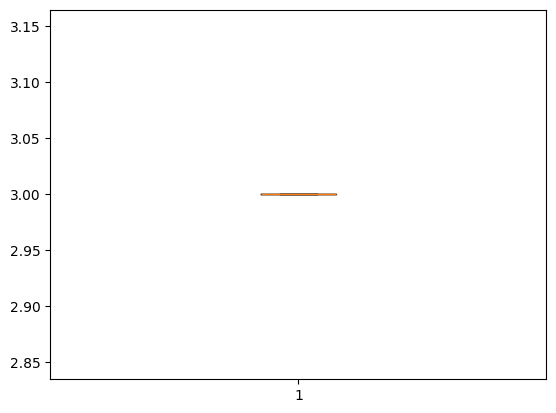

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'Gene': ['isg15', 'hur', 'ifna', 'tnfa', 'atpsf1a'],
    'Acido_Glutamico': [2, 4, 1, 3, 2]
})

def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

print(f"IQR: {iqr(df['Acido_Glutamico'])}")

penultimo = df.iloc[-2, 1:]
print(f"IQR penúltimo: {iqr(penultimo)}")

plt.boxplot(penultimo)
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [5]:
import pandas as pd

df = pd.DataFrame({
    'Prolina': [2, 4, 1, 3, 2]
})

print(f"Variância: {df['Prolina'].var(ddof=1):.2f}")

Variância: 1.30


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [6]:
import pandas as pd

df = pd.DataFrame({'Triptofano': [2, 4, 1, 3, 2]})

print(f"Desvio padrão: {df['Triptofano'].std():.2f}")

Desvio padrão: 1.14


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [7]:
import pandas as pd

df = pd.DataFrame({'Leucina': [2, 4, 1, 3, 2]})

cv = df['Leucina'].std() / df['Leucina'].mean() * 100
print(f"CV: {cv:.2f}%")

CV: 47.51%


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [8]:
import pandas as pd

df = pd.DataFrame({'Alanina': [2, 4, 1, 3, 5, 2, 3, 4]})

def resumo(x):
    return {'min': x.min(), 'Q1': x.quantile(0.25), 'mediana': x.median(), 'Q3': x.quantile(0.75), 'max': x.max(), 'media': x.mean(), 'var': x.var(), 'dp': x.std(), 'cv': x.std()/x.mean()*100}

print(resumo(df['Alanina']))

{'min': np.int64(1), 'Q1': np.float64(2.0), 'mediana': np.float64(3.0), 'Q3': np.float64(4.0), 'max': np.int64(5), 'media': np.float64(3.0), 'var': np.float64(1.7142857142857142), 'dp': np.float64(1.3093073414159542), 'cv': np.float64(43.643578047198474)}


## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

Maior CV: hur


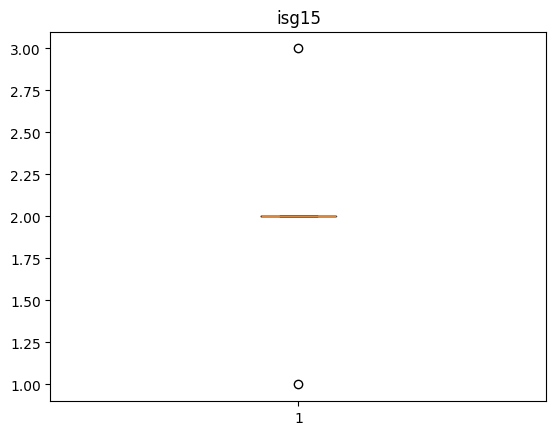

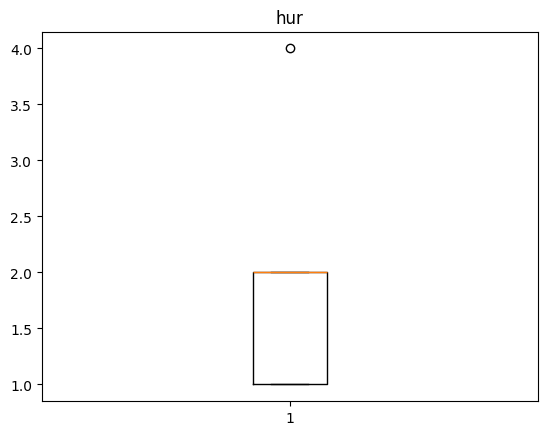

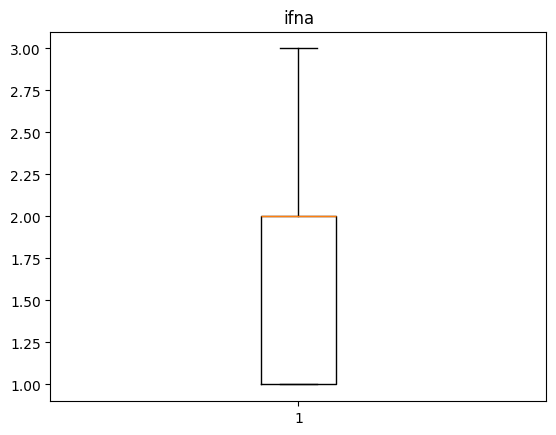

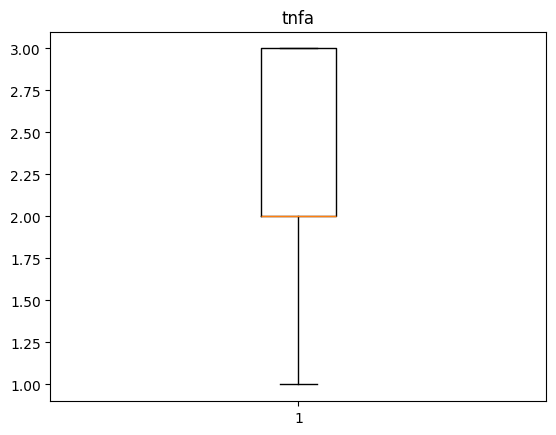

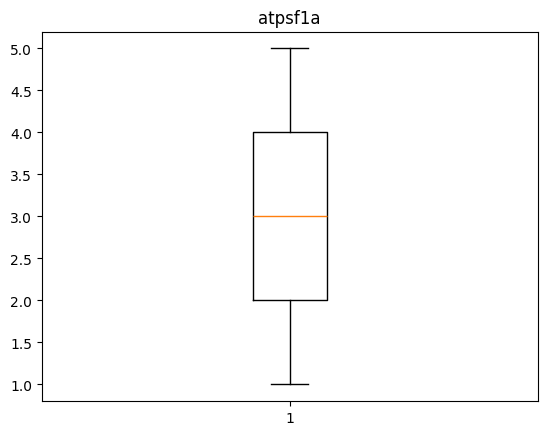

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'Gene': ['isg15', 'hur', 'ifna', 'tnfa', 'atpsf1a'],
    'aa': [[2,3,2,1,2], [4,2,1,2,1], [1,1,3,2,2], [3,3,2,1,2], [5,2,4,3,1]]
})

def cv(x):
    return (pd.Series(x).std() / pd.Series(x).mean()) * 100

df['CV'] = df['aa'].apply(cv)
print(f"Maior CV: {df.loc[df['CV'].idxmax(), 'Gene']}")

for i in range(len(df)):
    plt.boxplot(df.iloc[i, 1])
    plt.title(df.iloc[i, 0])
    plt.show()

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

Maior CV: Alanina (52.70%)


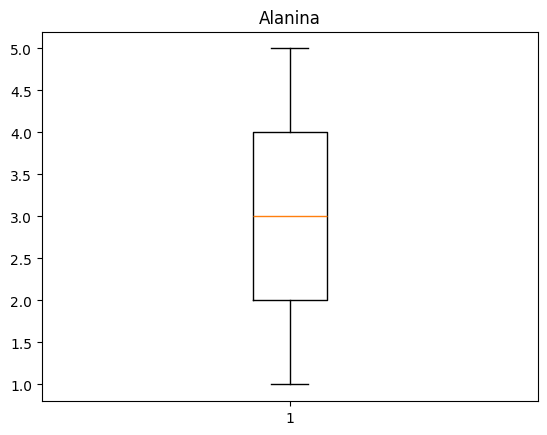

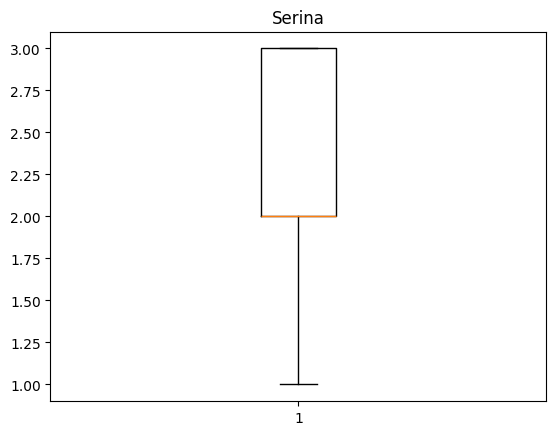

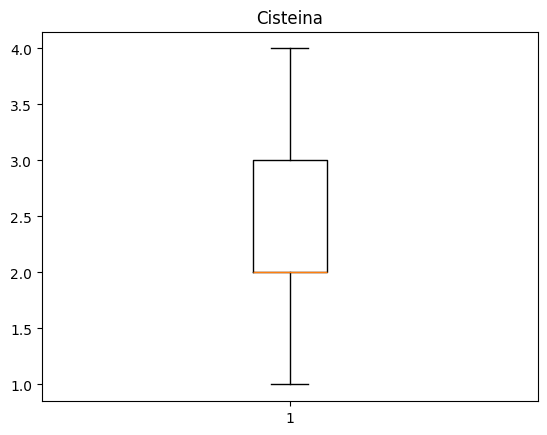

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'Alanina': [2, 4, 1, 3, 5],
    'Serina': [3, 2, 1, 3, 2],
    'Cisteina': [2, 1, 3, 2, 4]
})

cv = df.apply(lambda x: x.std()/x.mean()*100)
print(f"Maior CV: {cv.idxmax()} ({cv.max():.2f}%)")

for aa in df.columns:
    plt.boxplot(df[aa])
    plt.title(aa)
    plt.show()